# Thermal-Aware Energy Management System — Summary of Results

This notebook summarizes the key results of the project, drawing on saved outputs from
`03_multi_lap_DP.ipynb` and `04_multi_lap_DP_thermal.ipynb` rather than recomputing the
dynamic programming solutions here (each backward pass takes long enough that recomputing
three variants plus a thermal stress test in one notebook is impractical).

**Story in five parts:**
1. On a single qualifying lap, DP, ECMS and a rule-based heuristic are benchmarked through
   the same nonlinear plant, showing what knowledge of the future is worth and why power
   shortfall has to be reported alongside fuel.
2. A fuel-optimal baseline over a 5-lap race fully cycles the battery once per lap,
   reaching the SoC floor at every lap boundary and leaving no margin for the next lap.
3. An asymmetric soft constraint on end-of-lap SoC halves the residual shortfall at a
   quantified fuel cost — and the simpler constant floor turns out to beat the
   lap-dependent one.
4. A parametric cooling-degradation stress test shows the thermal derating bound is
   already active at nominal cooling, contradicting the hypothesis that SoC exhaustion
   would always mask it.
5. A fixed-point iteration between the DP policy and the thermal model corrects the
   open-loop assumption, cutting shortfall energy by two orders of magnitude without a
   full 3D state reformulation.

In [25]:
import numpy as np
import matplotlib.pyplot as plt

multi_lap = np.load('data/results/multi_lap_comparison.npz')
thermal = np.load('data/results/thermal_analysis.npz')

t = multi_lap['t']
N_lap = multi_lap['N_lap']
Pgb = multi_lap['Pgb']

## 1. Single-lap benchmark: DP vs ECMS vs rule-based

Before the multi-lap analysis, the three controllers are compared on a single qualifying
lap, all simulated through the same nonlinear plant from a full battery (SoC₀ = 0.9).

- **DP** has full knowledge of the future velocity profile. It is the benchmark, not an
  implementable controller.
- **ECMS** is instantaneous, but tracks the DP's SoC trajectory as a reference. It is
  therefore an upper bound on achievable ECMS performance rather than a fully causal
  strategy; the equivalence factor is anchored at the analytical break-even value
  1/η_ICE = 2.008, with proportional feedback on the SoC reference.
- **Rule-based** schedules the MGU-K power fraction linearly on SoC, with no optimization
  and no knowledge of the future.

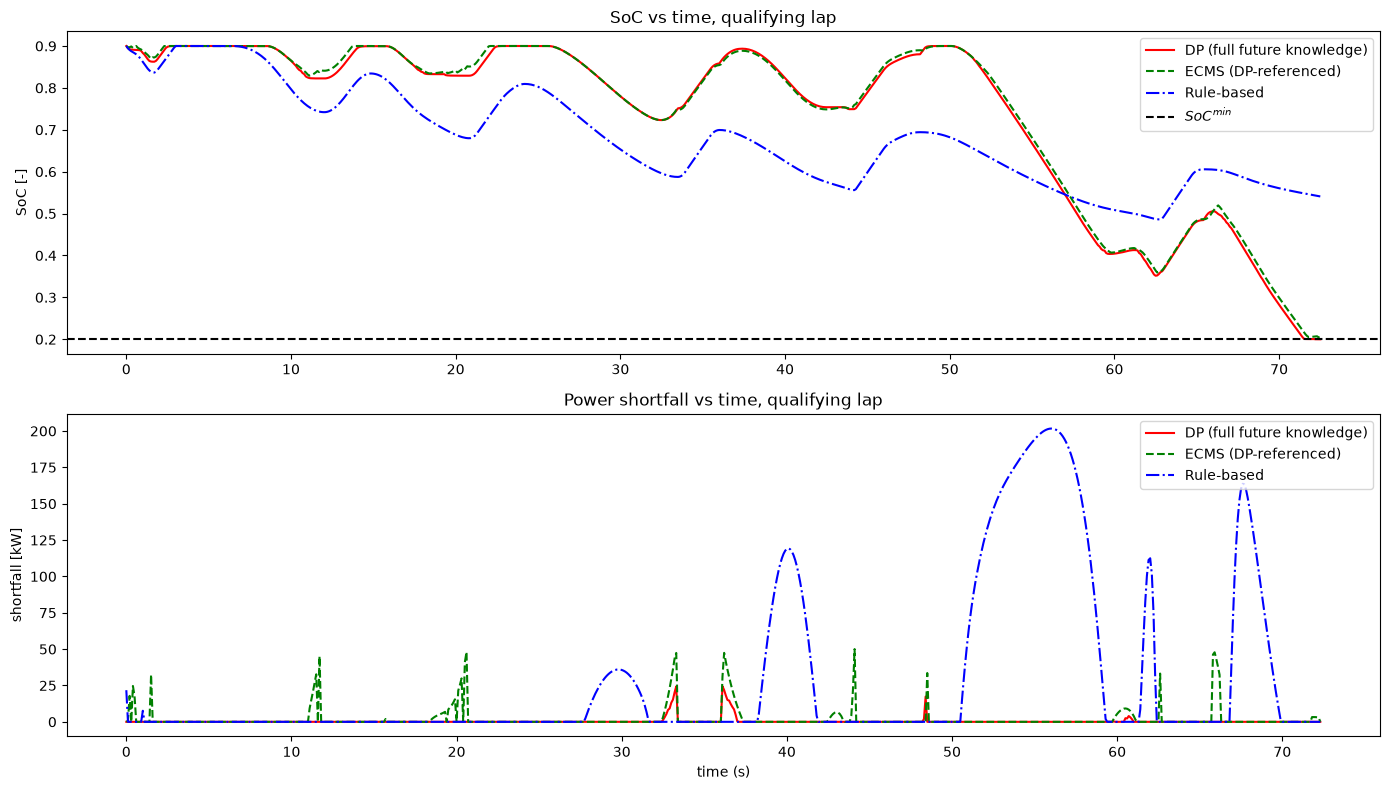

Controller                     Fuel [g]   SoC fin  Deploy [MJ]  Shortfall [MJ]
------------------------------------------------------------------------------
DP (full future knowledge)       805.48    0.2000        8.175           0.027
ECMS (DP-referenced)             820.09    0.2046        8.163           0.153
Rule-based                       773.50    0.5417        6.108           2.020


In [26]:
single = np.load('data/results/single_lap_comparison.npz')
t_q, Pgb_q = single['t'], single['Pgb']
dt_q = 0.1

cases = {'dp': ('DP (full future knowledge)', 'red', '-'),
         'ecms': ('ECMS (DP-referenced)', 'green', '--'),
         'rb': ('Rule-based', 'blue', '-.')}

fig, axs = plt.subplots(2, 1, figsize=(14, 8))

for key, (label, color, ls) in cases.items():
    axs[0].plot(t_q, single[f'SoC_{key}'], color=color, label=label, linestyle=ls)
axs[0].axhline(0.2, color='k', linestyle='--', label=r'$SoC^{min}$')
axs[0].set_ylabel('SoC [-]')
axs[0].set_title('SoC vs time, qualifying lap')
axs[0].legend(loc=1)

for key, (label, color, ls) in cases.items():
    axs[1].plot(t_q[:-2], single[f'shortfall_{key}'][:-2]/1e3, color=color, label=label, linestyle=ls)
axs[1].set_xlabel('time (s)')
axs[1].set_ylabel('shortfall [kW]')
axs[1].set_title('Power shortfall vs time, qualifying lap')
axs[1].legend(loc=1)

plt.tight_layout()
plt.show()

print(f"{'Controller':<28}{'Fuel [g]':>11}{'SoC fin':>10}{'Deploy [MJ]':>13}{'Shortfall [MJ]':>16}")
print("-" * 78)
for key, (label, _, _) in cases.items():
    fuel = np.sum(single[f'J_{key}']) * 1e3
    soc  = single[f'SoC_{key}'][-2]
    dep  = single[f'E_ES2K_{key}'][-2] / 1e6
    sf   = np.sum(single[f'shortfall_{key}']) * dt_q / 1e6
    print(f"{label:<28}{fuel:>11.2f}{soc:>10.4f}{dep:>13.3f}{sf:>16.3f}")

**Reading the table.** The comparison is meaningful only between DP and ECMS: both end the
lap at essentially the same SoC (0.2000 and 0.2046) and deploy nearly the same energy
(8.175 and 8.163 MJ), so the fuel figures describe the same amount of work done with the
same amount of stored energy. On that basis ECMS costs 820.09 g against the DP's 805.48 g,
a 1.8% penalty for giving up knowledge of the future — and it carries 0.153 MJ of shortfall
against 0.027 MJ, so part of that gap is paid in feasibility rather than fuel.

The rule-based row cannot be read the same way. Its 773.50 g is the lowest of the three, but
it ends the lap with SoC at 0.5417 — roughly 1.9 MJ of stored energy it never used — and
leaves 2.020 MJ of the power demand unmet, two orders of magnitude more than the DP. It burns
less fuel because it does less: less deployment, less work delivered. Without the shortfall
column the table would appear to show a heuristic beating the optimum, which is exactly why
the column is there.

The DP's own residual 0.027 MJ is what the shortfall penalty in the stage cost buys. The
ablation in `01b_single_lap_DP_vectorized.ipynb` removes that penalty and yields 623.90 g with
3.291 MJ of shortfall: 181 g of apparent fuel saving for 3.98 MJ of mechanical work never
delivered.

## 2. Baseline: fuel-optimal, feasible, but with no reserve

The baseline minimizes fuel plus a penalty on power shortfall, with no constraint on
end-of-lap SoC. The shortfall term matters: without it the optimizer meets less of the
demand at no cost, and the resulting policy is fuel-optimal only because it does less work
(quantified by the ablation in `01b_single_lap_DP_vectorized.ipynb`, where an unpenalized
single-lap policy leaves 3.291 MJ of demand unmet against 0.027 MJ for the penalized one).

With the penalty in place, the baseline is largely feasible. What it does not do is keep
any reserve. SoC starts each lap at 0.9, is drawn down through the lap, and reaches
$SoC^{min}$ at every lap boundary: the pack is fully cycled once per lap. That is forced by
the 2026 energy-store sizing — roughly 4 MJ of usable storage against a 9 MJ per-lap deploy
allowance — and it means each new lap begins with an empty battery, with no margin if a
traction peak arrives before regeneration has refilled it. The residual shortfall is
distributed across the race in short spikes rather than concentrated at the end.

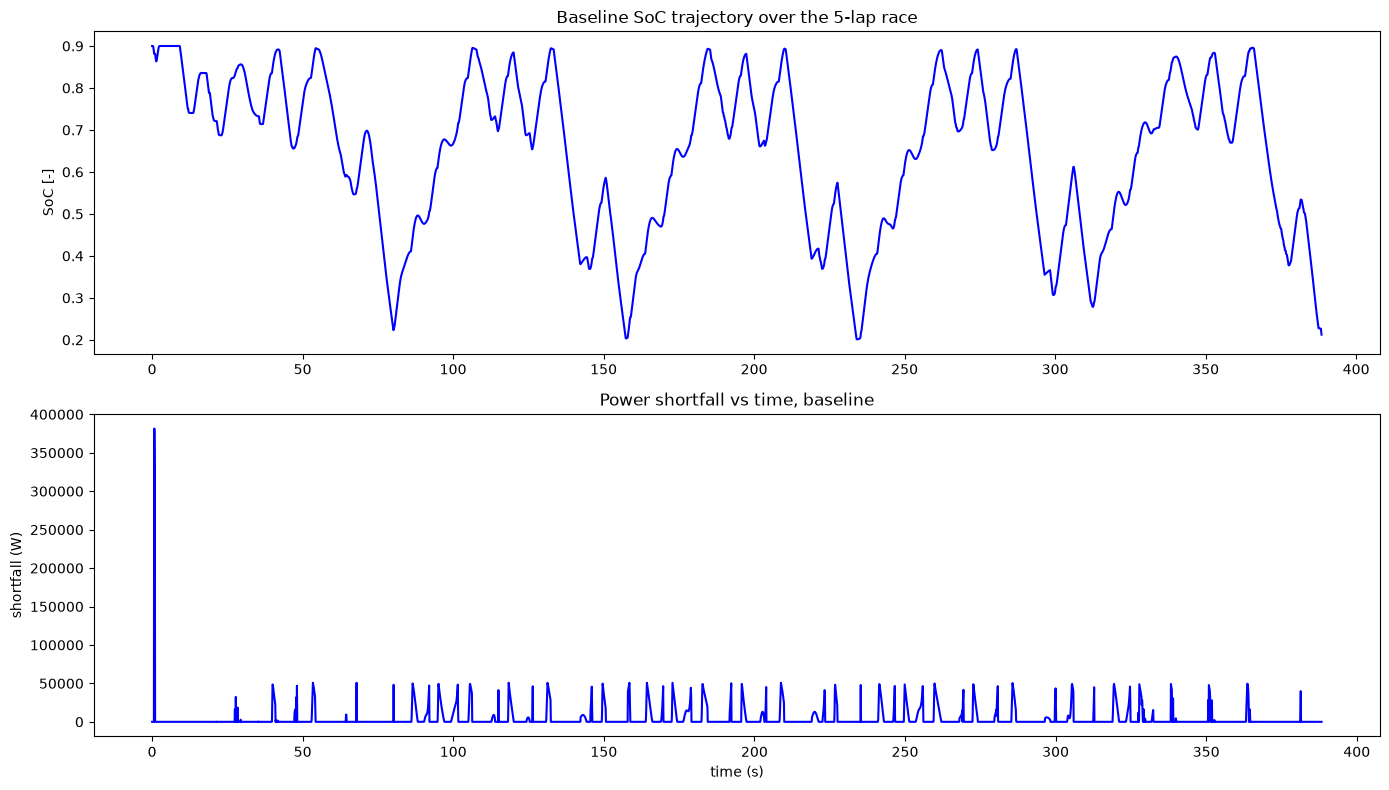

Baseline total fuel: 4153.63 g
Baseline total shortfall energy: 1.792 MJ


In [27]:
fig, axs = plt.subplots(2, 1, figsize=(14, 8))

axs[0].plot(t, multi_lap['SoC_baseline'], color='blue')
axs[0].set_ylabel('SoC [-]')
axs[0].set_title('Baseline SoC trajectory over the 5-lap race')

delivered_baseline = multi_lap['P_eng_baseline'] + multi_lap['P_mgu_baseline']
shortfall_baseline = np.maximum(0, Pgb - delivered_baseline)
axs[1].plot(t[0:-2], shortfall_baseline[0:-2], color='blue')
axs[1].set_xlabel('time (s)')
axs[1].set_ylabel('shortfall (W)')
axs[1].set_title('Power shortfall vs time, baseline')

plt.tight_layout()
plt.show()

print(f"Baseline total fuel: {np.sum(multi_lap['J_baseline'])*1e3:.2f} g")
print(f"Baseline total shortfall energy: {np.sum(shortfall_baseline)*0.1/1e6:.3f} MJ")

## 3. Leaving a reserve: asymmetric soft constraint on end-of-lap SoC

Rather than an equality target (which would penalize ending a lap with more charge than
needed, never a feasibility problem, only a fuel inefficiency the cost already accounts for),
a one-sided hinge penalty is added to the value function at every lap boundary, pushing SoC
upward only when it falls below a target. Two variants are compared against the baseline: a
fixed target (0.7 at every lap boundary) and a lap-dependent target, kept low early and
raised toward the end of the race.

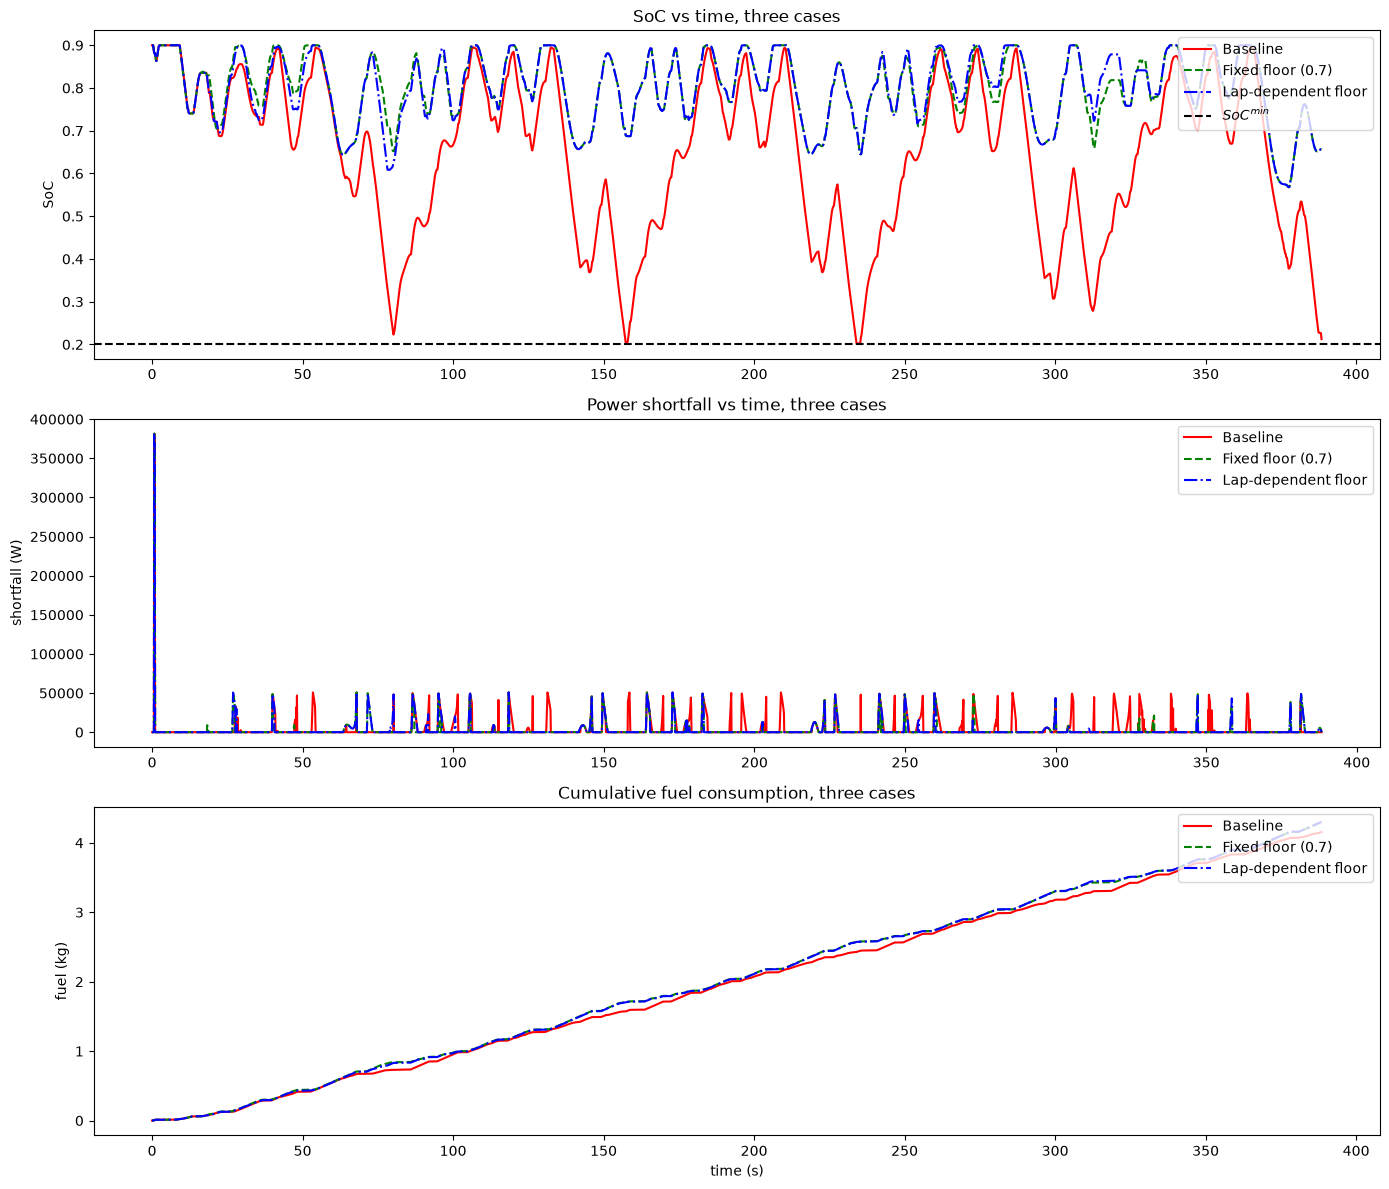

Case                    Fuel (g)    Shortfall energy (MJ)
Baseline                 4153.63                    1.792
Fixed floor (0.7)        4297.76                    0.896
Lap-dependent floor      4300.05                    1.011


In [28]:
fig, axs = plt.subplots(3, 1, figsize=(14, 12))
labels = {'baseline': ('Baseline', 'red', '-'), 'fixed': ('Fixed floor (0.7)', 'green','--'), 'variable': ('Lap-dependent floor', 'blue','-.')}

for key, (label, color, linestyle) in labels.items():
    axs[0].plot(t, multi_lap[f'SoC_{key}'], color=color, label=label, linestyle=linestyle)
axs[0].axhline(0.2, color='k', linestyle='--', label=r'$SoC^{min}$')
axs[0].set_ylabel('SoC')
axs[0].set_title('SoC vs time, three cases')
axs[0].legend(loc=1)

for key, (label, color, linestyle) in labels.items():
    delivered = multi_lap[f'P_eng_{key}'] + multi_lap[f'P_mgu_{key}']
    shortfall = np.maximum(0, Pgb - delivered)
    axs[1].plot(t[0:-2], shortfall[0:-2], color=color, label=label, linestyle= linestyle)
axs[1].set_ylabel('shortfall (W)')
axs[1].set_title('Power shortfall vs time, three cases')
axs[1].legend(loc=1)

for key, (label, color,linestyle) in labels.items():
    axs[2].plot(t, np.cumsum(multi_lap[f'J_{key}']), color=color, label=label, linestyle=linestyle)
axs[2].set_xlabel('time (s)')
axs[2].set_ylabel('fuel (kg)')
axs[2].set_title('Cumulative fuel consumption, three cases')
axs[2].legend(loc=1)

plt.tight_layout()
plt.show()

print(f"{'Case':<20}{'Fuel (g)':>12}{'Shortfall energy (MJ)':>25}")
for key, (label, _,_) in labels.items():
    fuel = np.sum(multi_lap[f'J_{key}'])*1e3
    delivered = multi_lap[f'P_eng_{key}'] + multi_lap[f'P_mgu_{key}']
    shortfall_energy = np.sum(np.maximum(0, Pgb - delivered))*0.1/1e6
    print(f"{label:<20}{fuel:>12.2f}{shortfall_energy:>25.3f}")


**Reading the trade-off.** The fixed floor halves the shortfall energy, from 1.792 MJ to
0.896 MJ, for 144 g of extra fuel (+3.5%). The SoC panel shows the mechanism directly: both
constrained cases hold SoC above roughly 0.53 for the whole race instead of cycling down to
the floor, so usable charge is always available when a traction peak arrives.

Between the two variants the fixed floor wins on **both** axes: 0.896 MJ against 1.011 MJ of
shortfall, and 2.3 g less fuel. The fuel difference is below the resolution of the state grid
and should not be read as a ranking, but the 11% gap in shortfall energy is real.

This is the opposite of the design intent behind the lap-dependent schedule, which assumed
the early laps need no margin and that relaxing the floor there would buy back fuel. Neither
half holds: the residual shortfall is spread across the whole race, so relaxing the floor
early removes margin where it is still being used, and the fuel it was meant to save does not
materialize because the floor is not what dominates consumption. With this energy-store
sizing the binding quantity is the size of the store itself, not where the end-of-lap target
is placed — a uniform floor captures the available benefit, and shaping it lap by lap adds a
tuning parameter without adding performance. Reported as found, not adjusted to match the
original expectation.

## 4. When does the thermal constraint matter?

This section was built to test the hypothesis that SoC exhaustion always binds before the
thermal constraint: that the policy would have stopped deploying for lack of charge before
the pack was hot enough for derating to matter. The stress test refutes it. The derating
bound is already active at nominal cooling, for 261 of the race's stages.

The reason is the pack itself. Roughly 4 MJ of usable storage delivering up to 350 kW implies
a very high C-rate, and the resulting Joule heating pushes the battery above the 45 °C
derating threshold well before the SoC floor is reached. The two constraints overlap rather
than acting in sequence.

Since the thermal parameters are estimated from published cell data rather than calibrated
against a real pack, and no 2026 telemetry exists yet for circuits with more demanding
thermal conditions, the sensitivity is characterized through a parametric stress test on
cooling effectiveness rather than a track-to-track comparison. Binding instants grow roughly
six-fold as cooling effectiveness is cut to 30%.

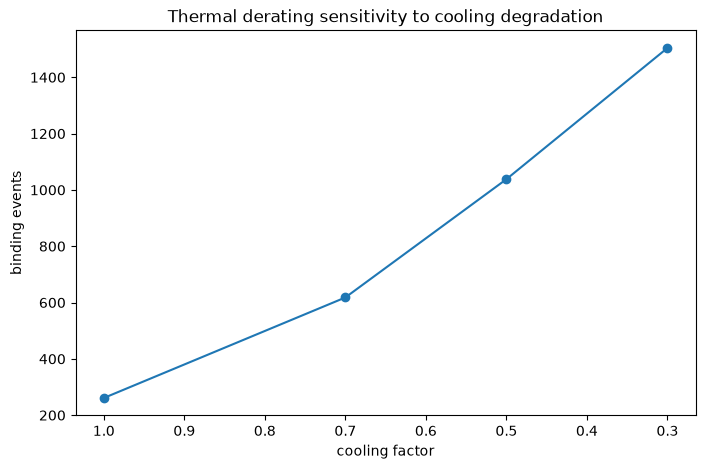

At nominal cooling: 261 binding events
At 30% cooling effectiveness: 1504 binding events, shortfall energy 12.397 MJ


In [29]:
plt.figure(figsize=(8, 5))
plt.plot(thermal['cfs'], thermal['binding_counts'], 'o-')
plt.xlabel('cooling factor')
plt.ylabel('binding events')
plt.title('Thermal derating sensitivity to cooling degradation')
plt.gca().invert_xaxis()
plt.show()


print(f"At nominal cooling: {thermal['binding_counts'][0]} binding events")
print(f"At 30% cooling effectiveness: {thermal['binding_counts'][-1]} binding events, "
      f"shortfall energy {thermal['shortfall_energy'][-1]:.3f} MJ")


## 5. Closing the loop: fixed-point self-consistency under degraded cooling

Enforcing a derated bound built from one policy's currents is only self-consistent if the
resulting policy does not draw current differently enough to change the temperature profile
that produced the bound. Under degraded cooling this assumption breaks: a tighter bound
changes the policy, which changes the currents, which changes the temperature. Rather than
promoting temperature to a full third DP state, self-consistency is recovered through
fixed-point iteration between the backward pass and the thermal model, on the same 2D grid.

The iteration converges in 11 passes, from 10.372 °C to 0.292 °C of residual. Convergence is
not monotone — expected, since the DP control map is bang-bang on a discrete grid, so the map
from temperature profile to policy is discontinuous and the iteration is damped rather than
being a contraction in any proven sense. Simulating the converged policy fresh, without the
relaxation smoothing, gives a temperature profile within 0.219 °C of the one it was optimized
against.

Both rows below are simulated at 30% cooling effectiveness, so only the policy differs.
Shortfall energy falls by 99.1% for a fuel penalty of 101 g (+2.9%). Note the asymmetry
between the two columns: binding instants fall by only 38% while the energy behind them falls
by two orders of magnitude — the thermal-aware policy has not stopped touching the bound, it
has eliminated the deep violations and left only instants that graze it.

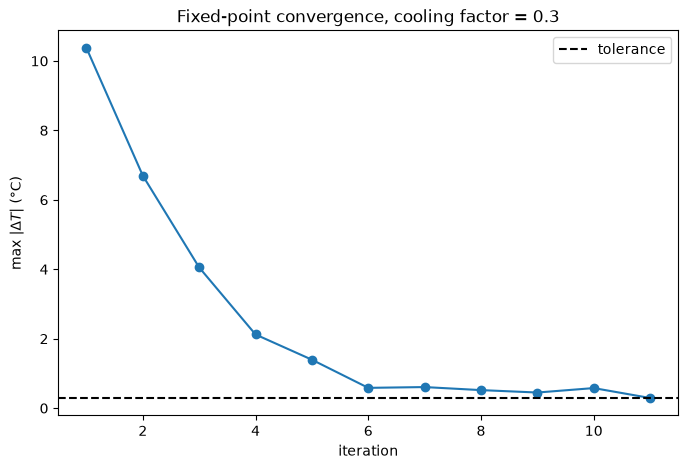

                          Binding events  Shortfall [MJ]   Fuel [g]
Open-loop (before)                  1503          12.116    3479.46
Fixed-point (after)                  937           0.108    3580.28


In [30]:
plt.figure(figsize=(8, 5))
deltas = thermal['delta_history']
plt.plot(range(1, len(deltas)+1), deltas, 'o-')
plt.axhline(0.3, color='k', linestyle='--', label='tolerance')
plt.xlabel('iteration')
plt.ylabel(r'max $|\Delta T|$ (°C)')
plt.title('Fixed-point convergence, cooling factor = 0.3')
plt.legend()
plt.show()


print(f"{'':<24}{'Binding events':>16}{'Shortfall [MJ]':>16}{'Fuel [g]':>11}")
print(f"{'Open-loop (before)':<24}{thermal['binding_before']:>16}{thermal['sf_before']:>16.3f}{thermal['fuel_before']:>11.2f}")
print(f"{'Fixed-point (after)':<24}{thermal['binding_after']:>16}{thermal['sf_after']:>16.3f}{thermal['fuel_after']:>11.2f}")

## Conclusions and future work

- **Penalizing power shortfall is not optional in a fuel-minimizing DP.** Left out, the
  optimizer meets less of the demand at no cost: on a single lap it leaves 3.291 MJ unmet
  against 0.027 MJ once penalized, and reports 181 g less fuel for work it never did.
- **The 2026 energy-store sizing is the dominant constraint of the whole problem.** With
  ~4 MJ usable against a 9 MJ per-lap deploy allowance, the battery is fully cycled once per
  lap, and both the SoC and the thermal results follow from that.
- **An asymmetric soft constraint on end-of-lap SoC halves the residual shortfall** (1.792 →
  0.896 MJ) for 144 g of fuel. The simpler constant floor beats the lap-dependent one on both
  fuel and shortfall, contradicting the intent behind the latter.
- **Thermal derating is already active at nominal cooling** (261 binding instants), not
  masked by SoC exhaustion as initially hypothesized, and tightens sharply as cooling
  degrades.
- **Fixed-point iteration between the DP policy and the thermal model** cuts shortfall energy
  under degraded cooling by 99.1% for +2.9% fuel, at a fraction of the cost of a full 3D state
  reformulation — a deliberate cost/accuracy trade-off, made explicit rather than hidden.
- **Known simplifications carried through the project**: the DP and ECMS backward passes omit
  `R_int` losses in the stage cost while the forward pass uses the full nonlinear plant (the
  mismatch is quantified rather than hidden); `R_int` is treated as constant, not
  temperature-dependent; the per-lap regenerated energy is not capped; and the thermal
  parameters are estimated from published cell data rather than calibrated against a real pack.
- **Reinforcement learning (SAC) is deferred as future work**, given the September 2026
  deadline and the priority of finishing this deterministic framework to a high standard first.